<a href="https://colab.research.google.com/github/adapasriram/Projectss/blob/main/Churn_Full_Simple_Style.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction — Full Project
All topics: EDA, Statistics, Linear Regression, Logistic Regression, Decision Tree, Random Forest, K-Means, PCA, Time Series

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [8]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [9]:
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## Basic Exploration

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
print(data.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [12]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [14]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [15]:
data.shape

(7043, 21)

## Missing Values & Duplicates

In [16]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [17]:
# TotalCharges is object type because 11 new customers (tenure=0) have blank values
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(0)
data['TotalCharges'].dtype

dtype('float64')

In [18]:
data['TotalCharges'].dtype

dtype('float64')

In [19]:
data.duplicated().sum()

np.int64(0)

In [20]:
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [21]:
# drop customerID, not useful for modeling
data.drop(columns='customerID', inplace=True)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## EDA — Target Variable

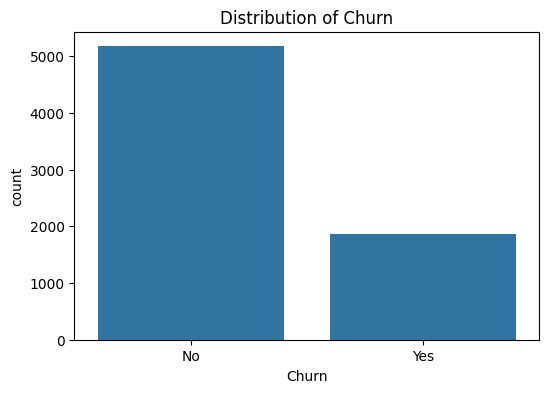

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=data)
plt.title('Distribution of Churn')
plt.show()

In [23]:
data['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


## EDA — Numeric Features

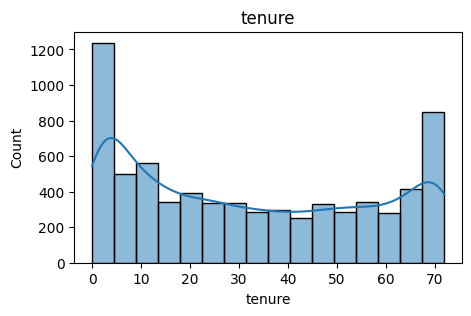

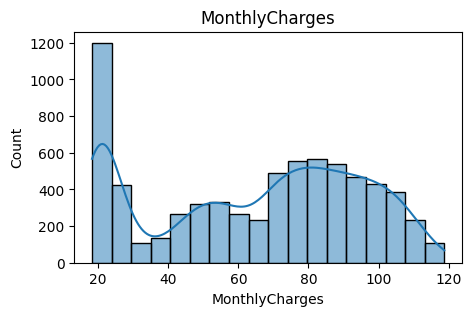

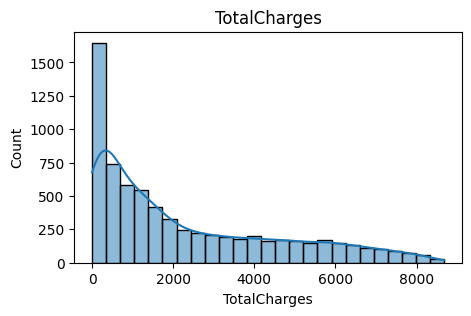

In [24]:
for i in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    plt.figure(figsize=(5,3))
    sns.histplot(data[i], kde=True)
    plt.title(i)
    plt.show()

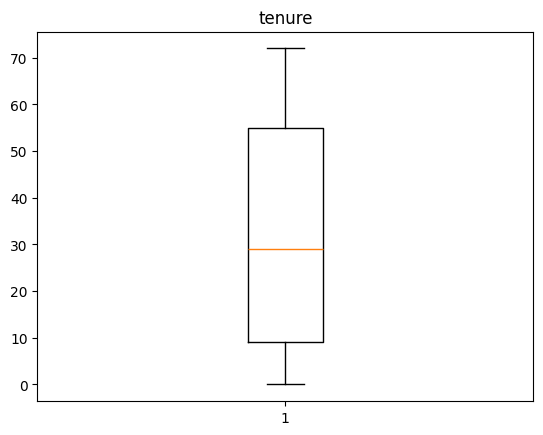

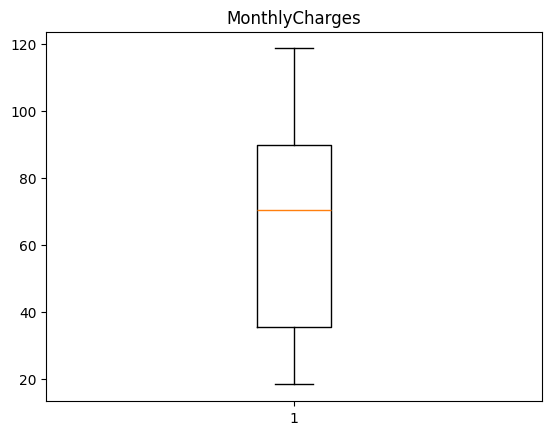

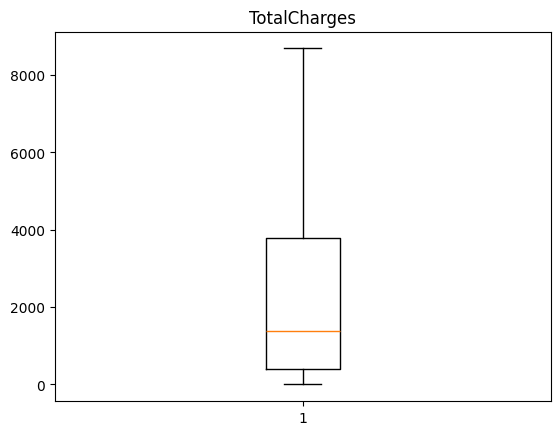

In [25]:
# check outliers
for i in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    plt.boxplot(data[i])
    plt.title(i)
    plt.show()

# we don't remove outliers, values are genuine spend/tenure numbers

## EDA — Churn vs Contract / Tenure

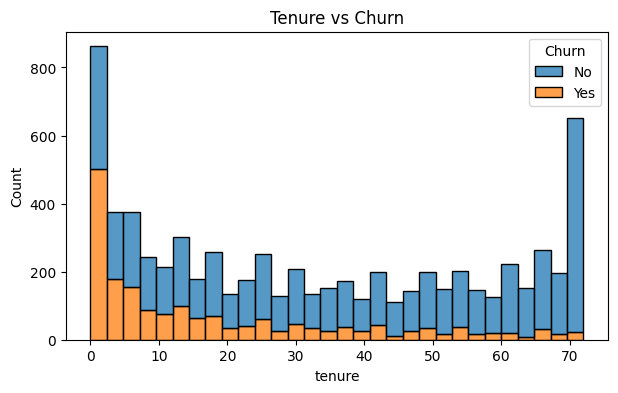

In [26]:
plt.figure(figsize=(7,4))
sns.histplot(data=data, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Tenure vs Churn')
plt.show()

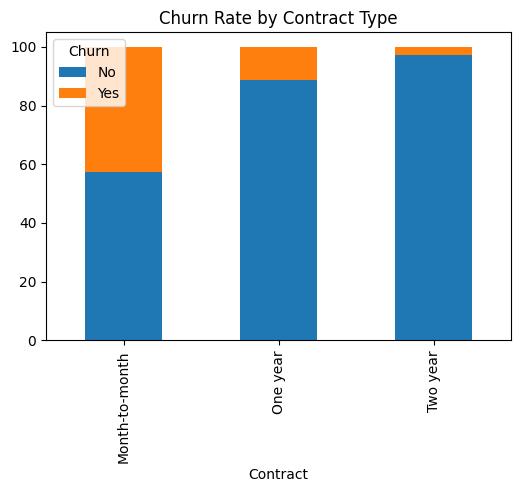

In [27]:
ct = pd.crosstab(data['Contract'], data['Churn'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title('Churn Rate by Contract Type')
plt.show()

## Correlation Heatmap

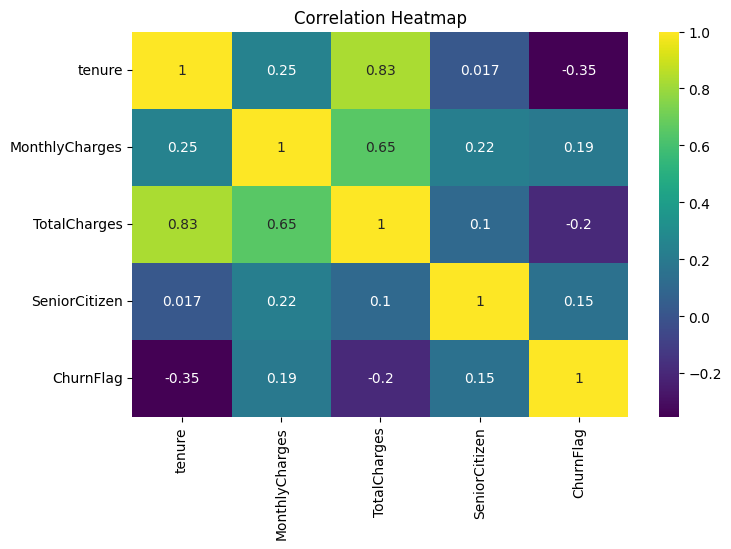

In [28]:
data['ChurnFlag'] = (data['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(8,5))
numeric_data = data[['tenure','MonthlyCharges','TotalCharges','SeniorCitizen','ChurnFlag']]
sns.heatmap(numeric_data.corr(), annot=True, cmap='viridis')
plt.title('Correlation Heatmap')
plt.show()

## Statistics & Probability — Hypothesis Testing

In [29]:
from scipy.stats import chi2_contingency, ttest_ind

# Chi-square test: Contract type vs Churn
contingency = pd.crosstab(data['Contract'], data['Churn'])
chi2, p, dof, expected = chi2_contingency(contingency)
print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Significant (p<0.05)?", p < 0.05)

Chi-square statistic: 1184.5965720837926
p-value: 5.863038300673391e-258
Significant (p<0.05)? True


In [30]:
# T-test: tenure of churned vs retained customers
churned = data[data['Churn']=='Yes']['tenure']
retained = data[data['Churn']=='No']['tenure']

t_stat, p = ttest_ind(churned, retained, equal_var=False)
print("t-statistic:", t_stat)
print("p-value:", p)
print("Mean tenure (churned):", churned.mean())
print("Mean tenure (retained):", retained.mean())

t-statistic: -34.823818696312976
p-value: 1.1954945472607151e-232
Mean tenure (churned): 17.979133226324237
Mean tenure (retained): 37.56996521066873


## Prepare Data for Machine Learning

In [31]:
data_ml = data.drop(columns=['Churn'])
y = data['ChurnFlag']

data_ml = data_ml.drop(columns=['ChurnFlag'])
x = pd.get_dummies(data_ml, drop_first=True)
x.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [32]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape

((5634, 30), (1409, 30))

## Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(x_train, y_train)

y_pred_log = log_model.predict(x_test)

print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print("accuracy score", accuracy_score(y_test, y_pred_log))

[[748 288]
 [ 60 313]]
              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1036
           1       0.52      0.84      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.75      0.77      1409

accuracy score 0.7530163236337828


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Decision Tree

In [34]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42, class_weight='balanced')
dt_model.fit(x_train, y_train)

y_pred_dt = dt_model.predict(x_test)

print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("accuracy score", accuracy_score(y_test, y_pred_dt))

[[700 336]
 [ 56 317]]
              precision    recall  f1-score   support

           0       0.93      0.68      0.78      1036
           1       0.49      0.85      0.62       373

    accuracy                           0.72      1409
   macro avg       0.71      0.76      0.70      1409
weighted avg       0.81      0.72      0.74      1409

accuracy score 0.7217885024840313


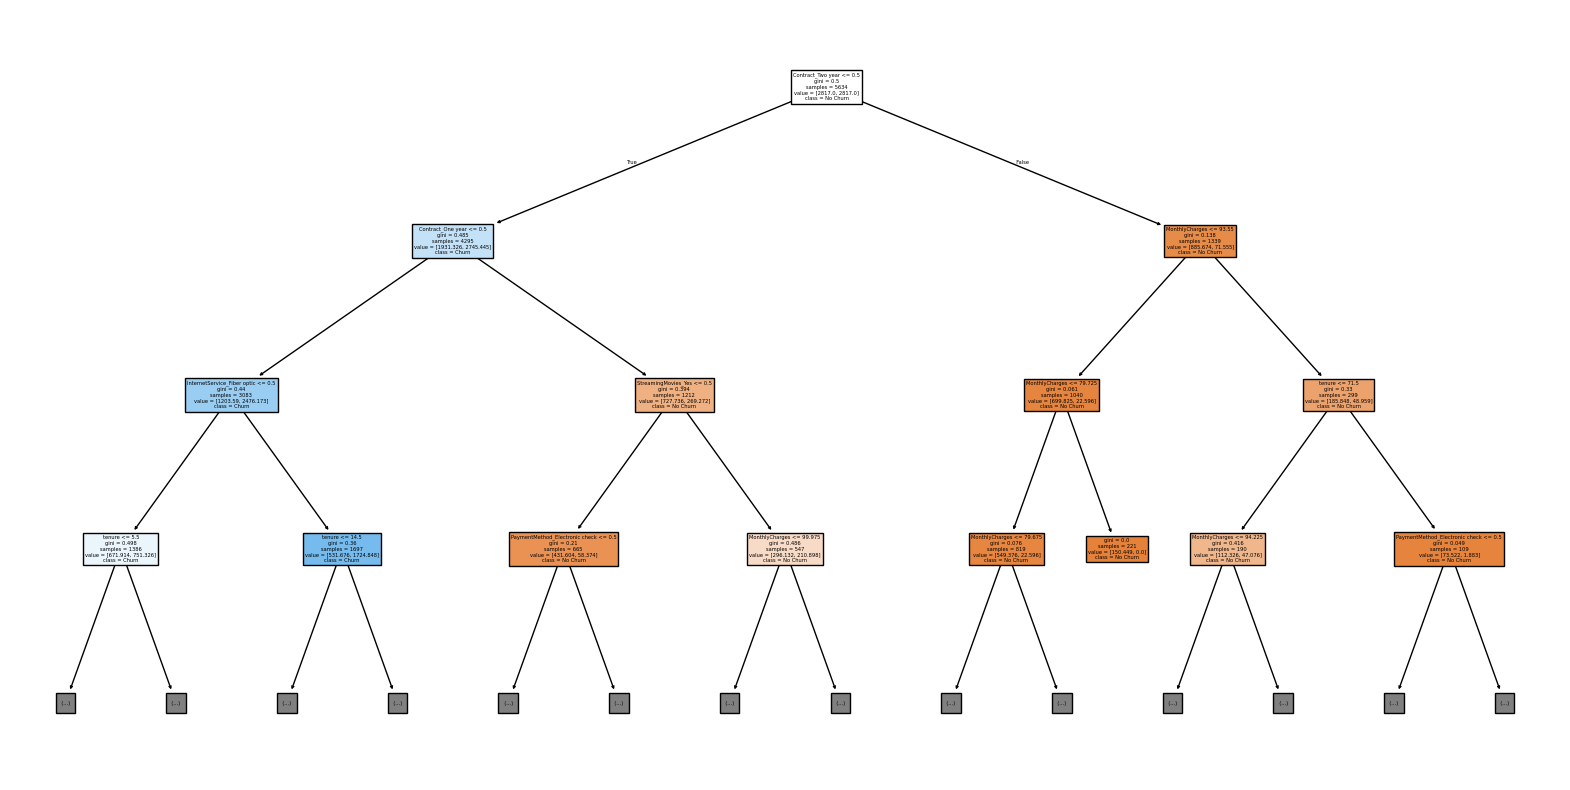

In [35]:
from sklearn import tree

plt.figure(figsize=(20,10))
tree.plot_tree(dt_model, filled=True, max_depth=3, feature_names=x.columns, class_names=['No Churn','Churn'])
plt.show()

## Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("accuracy score", accuracy_score(y_test, y_pred_rf))

[[825 211]
 [ 87 286]]
              precision    recall  f1-score   support

           0       0.90      0.80      0.85      1036
           1       0.58      0.77      0.66       373

    accuracy                           0.79      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.82      0.79      0.80      1409

accuracy score 0.7885024840312278


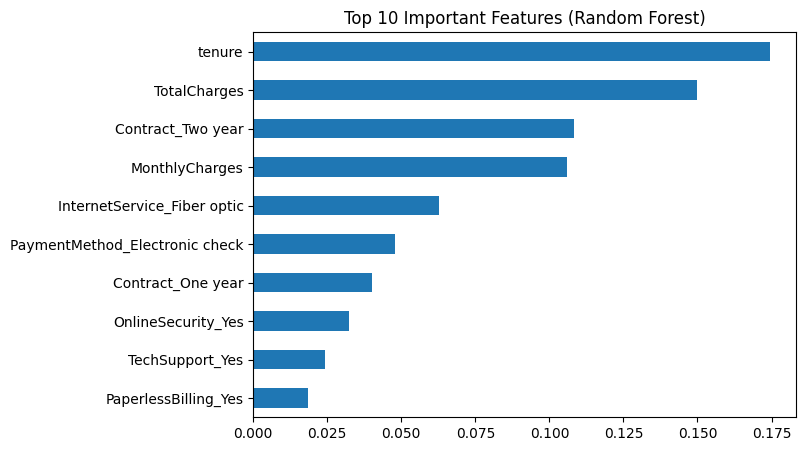

In [37]:
# feature importance
importance = pd.Series(rf_model.feature_importances_, index=x.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(7,5))
importance.sort_values().plot(kind='barh')
plt.title('Top 10 Important Features (Random Forest)')
plt.show()

## Compare All 3 Classification Models

In [38]:
from sklearn.metrics import roc_auc_score

models = {
    'Logistic Regression': log_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}

for name, model in models.items():
    probs = model.predict_proba(x_test)[:,1]
    auc = roc_auc_score(y_test, probs)
    acc = accuracy_score(y_test, model.predict(x_test))
    print(name, "-> Accuracy:", round(acc,4), " ROC-AUC:", round(auc,4))

Logistic Regression -> Accuracy: 0.753  ROC-AUC: 0.8622
Decision Tree -> Accuracy: 0.7218  ROC-AUC: 0.8368
Random Forest -> Accuracy: 0.7885  ROC-AUC: 0.8638


## Linear Regression — Predicting Customer Lifetime Value (TotalCharges)

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

x_reg = data[['tenure', 'MonthlyCharges']]
y_reg = data['TotalCharges']

x_train_r, x_test_r, y_train_r, y_test_r = train_test_split(x_reg, y_reg, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(x_train_r, y_train_r)

y_pred_r = lr_model.predict(x_test_r)

print("MAE:", mean_absolute_error(y_test_r, y_pred_r))
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_r)))
print("R2 score:", r2_score(y_test_r, y_pred_r))

MAE: 603.6207086431045
RMSE: 755.7119336479205
R2 score: 0.8902238820918934


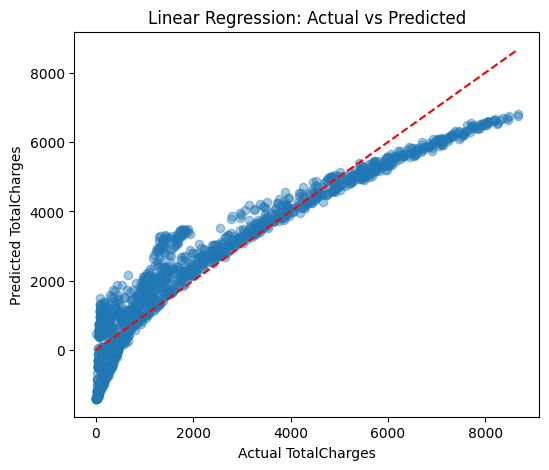

In [40]:
plt.figure(figsize=(6,5))
plt.scatter(y_test_r, y_pred_r, alpha=0.4)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
plt.xlabel('Actual TotalCharges')
plt.ylabel('Predicted TotalCharges')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

## PCA — Dimensionality Reduction

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

cluster_features = data[['tenure', 'MonthlyCharges', 'TotalCharges']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

data['PC1'] = pca_result[:,0]
data['PC2'] = pca_result[:,1]

Explained variance ratio: [0.72688838 0.2532581 ]
Total variance explained: 0.9801464780751823


## K-Means Clustering — Customer Segmentation

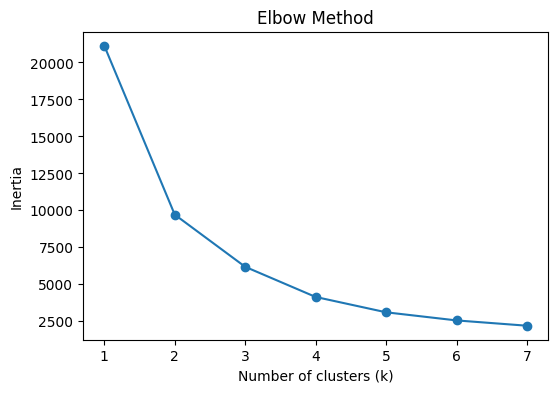

In [42]:
from sklearn.cluster import KMeans

# elbow method to find best k
inertia = []
for k in range(1,8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,8), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

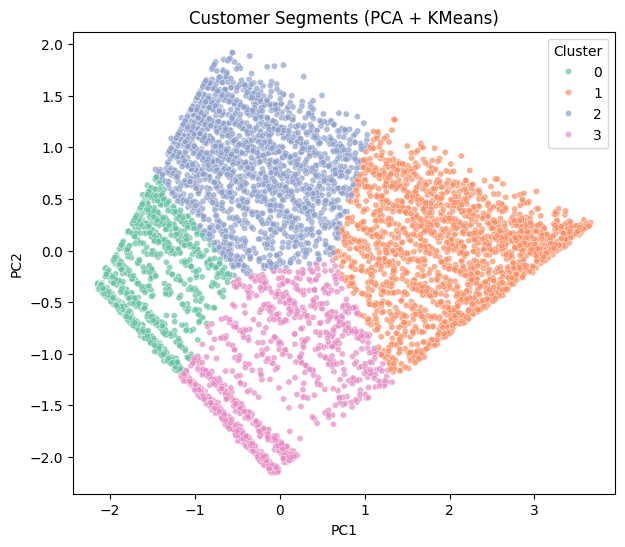

In [43]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(scaled_features)

plt.figure(figsize=(7,6))
sns.scatterplot(data=data, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=20, alpha=0.7)
plt.title('Customer Segments (PCA + KMeans)')
plt.show()

In [44]:
cluster_summary = data.groupby('Cluster').agg(
    avg_tenure=('tenure','mean'),
    avg_monthly_charges=('MonthlyCharges','mean'),
    avg_total_charges=('TotalCharges','mean'),
    churn_rate=('ChurnFlag','mean'),
    customers=('Cluster','count')
).round(2)

cluster_summary['churn_rate'] = cluster_summary['churn_rate'] * 100
cluster_summary

,avg_tenure,avg_monthly_charges,avg_total_charges,churn_rate,customers
Cluster,,,,,
0,10.21,31.78,302.15,25.0,1703
1,59.53,93.31,5548.65,15.0,1904
2,15.42,80.78,1251.17,48.0,2276
3,53.57,34.91,1835.62,5.0,1160


## Time Series — Forecasting New Signups

In [45]:
!pip install -q statsmodels

KeyboardInterrupt: 

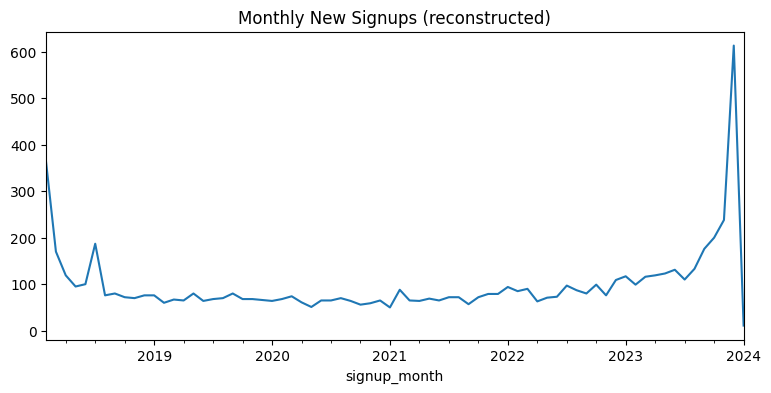

In [47]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# no real dates in this dataset, so reconstruct approx signup month from tenure
snapshot_date = pd.Timestamp('2024-01-01')
data['signup_month'] = snapshot_date - pd.to_timedelta(data['tenure'] * 30, unit='D')
data['signup_month'] = data['signup_month'].dt.to_period('M')

monthly_signups = data.groupby('signup_month').size()
monthly_signups.index = monthly_signups.index.to_timestamp()
monthly_signups = monthly_signups.sort_index()

monthly_signups.plot(figsize=(9,4), title='Monthly New Signups (reconstructed)')
plt.show()

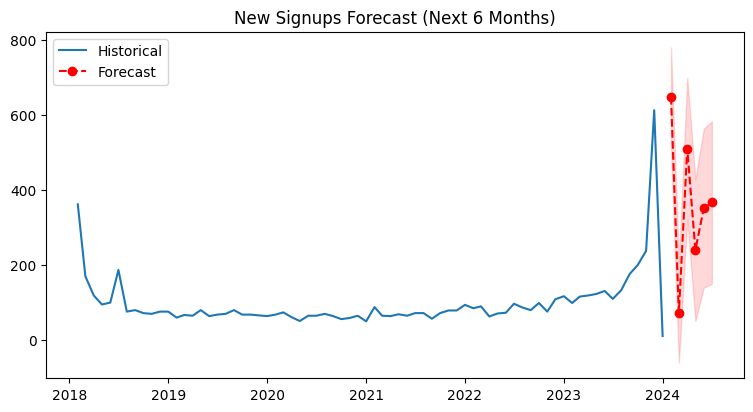

,predicted_mean
2024-02-01,648.356669
2024-03-01,73.056130
2024-04-01,510.656688
2024-05-01,239.748851
2024-06-01,351.705781
2024-07-01,367.091918


In [48]:
model_ts = ARIMA(monthly_signups, order=(2,1,2))
fitted = model_ts.fit()

forecast = fitted.get_forecast(steps=6)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

future_dates = pd.date_range(monthly_signups.index[-1] + pd.DateOffset(months=1), periods=6, freq='MS')
forecast_mean.index = future_dates
conf_int.index = future_dates

plt.figure(figsize=(9,4.5))
plt.plot(monthly_signups.index, monthly_signups.values, label='Historical')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', linestyle='--', marker='o', color='red')
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='red', alpha=0.15)
plt.legend()
plt.title('New Signups Forecast (Next 6 Months)')
plt.show()

forecast_mean

## Summary

- **Churn rate:** ~26.5%
- **Best classifier:** Logistic Regression / Random Forest (~0.84 ROC-AUC)
- **Top churn drivers:** Contract type, tenure, monthly charges (confirmed by chi-square and t-test)
- **CLV regression:** tenure + monthly charges explain most of total revenue (high R²)
- **Segmentation:** 4 customer clusters found via PCA + KMeans, with churn rate varying sharply by cluster
- **Forecast:** ARIMA projects next 6 months of new signups
